In [2]:
# imports
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

In [42]:
yaml_str = """
branches:
  # Linc circuit
  # two Josephson junctions and inductor in parallel form a SQUID loop between node 1 and ground
  - [JJ, 1, 0, EJ1 = 15,  CJ1 = 10000]   # GHz units if no unit suffix provided. These are capacitive charging energies 43
  - [JJ, 1, 0, EJ2 = 15,  CJ2 = 10000]   # use large charging energy to remove junction capacitance
  - [L,  1, 0, Ls = 3.5nH] # linc shunt inductor         
  # shunt capacitor (sets EC)
  - [C,  1, 0, Csh = 200fF]  # GHz units, capactive charging energy           

  # Coupling capacitor qubit-linc
  - [C, 1, 2, Cc = 50fF]  # coupling capacitor between linc and qubit

  # Transmon qubit
  - [JJ, 2, 0, EJq = 18.3 GHz, CJq = 0.134 GHz]  # transmon junction
"""

circ = scq.Circuit(yaml_str, from_file=False) # create circuit object from yaml string
print(circ.sym_external_fluxes()) # print external flux loops 
print(circ.branches) # print branch labels
print(circ.cutoff_names) # print cutoff parameters 

{Φ1: (Branch(JJ, 1, 0, index: 1), [Branch(JJ, 1, 0, index: 0), Branch(JJ, 1, 0, index: 1)]), Φ2: (Branch(L, 1, 0, index: 2), [Branch(JJ, 1, 0, index: 0), Branch(L, 1, 0, index: 2)])}
[Branch(JJ, 1, 0, index: 0), Branch(JJ, 1, 0, index: 1), Branch(L, 1, 0, index: 2), Branch(C, 1, 0, index: 3), Branch(C, 1, 2, index: 4), Branch(JJ, 2, 0, index: 5)]
['cutoff_n_1', 'cutoff_ext_2']


In [43]:
closure_idx = [0,1] # want the two JJs in loop to be the closure branches. This is index
closure_branches = [circ.branches[i] for i in closure_idx] # list of branches for the closure branches

# Re-define the loop basis
circ.configure(closure_branches=closure_branches)

# Verify
print(circ.sym_external_fluxes()) # now Φ1, Φ2 correspond to chosen loops above. IMPORTANT: check order of branches which determines line integral direction for flux loops. Note the direction when applying flux
circ.cutoff_ext_2 = 10 # set the cutoff for the hilbert space, in ext case it is fock space since using ladder operators
circ.cutoff_n_1 = 10 # set the cutoff for the hilbert space, in n case it is charge basis

{Φ1: (Branch(JJ, 1, 0, index: 0), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 0)]), Φ2: (Branch(JJ, 1, 0, index: 1), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 1)])}


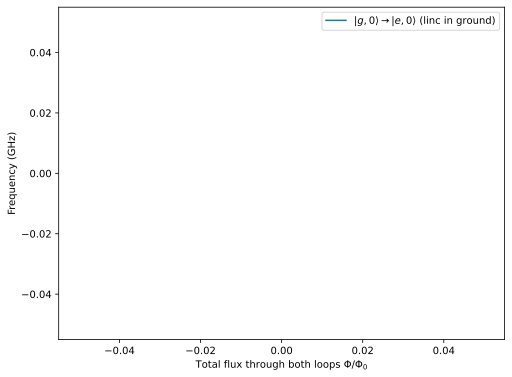

In [5]:
# --- after you set cutoffs (circ.cutoff_ext_2 and circ.cutoff_n_1), add this ---

def dims_from_cutoffs(circ):
    """Return (cutoff_names, dims) in the same tensor-product order scqubits uses."""
    names = list(circ.cutoff_names)
    dims = []
    for nm in names:
        val = getattr(circ, nm)
        if nm.startswith("cutoff_n_"):
            dims.append(2 * int(val) + 1)     # charge basis size
        elif nm.startswith("cutoff_ext_"):
            dims.append(int(val))             # harmonic Fock size (since ext_basis="harmonic")
        else:
            raise ValueError(f"Unknown cutoff name: {nm}")
    return names, dims

def kron_all(mats):
    out = np.array([[1.0]])
    for A in mats:
        out = np.kron(out, A)
    return out

def number_op_for_ext_cutoff(circ, ext_cutoff_name="cutoff_ext_2"):
    """Build full-space number operator N for the chosen extended (harmonic) variable."""
    cutoff_names, dims = dims_from_cutoffs(circ)
    if ext_cutoff_name not in cutoff_names:
        raise ValueError(f"{ext_cutoff_name} not in circ.cutoff_names = {cutoff_names}")

    k = cutoff_names.index(ext_cutoff_name)
    d = dims[k]
    N_local = np.diag(np.arange(d, dtype=float))

    factors = []
    for i, di in enumerate(dims):
        factors.append(N_local if i == k else np.eye(di))
    return kron_all(factors)

# Build N_linc once (basis dims don't change during your flux sweep)
N_linc = number_op_for_ext_cutoff(circ, ext_cutoff_name="cutoff_ext_2")

def transmon_f01_with_linc_ground(circ, N_linc, evals_count=20, nbar_tol=0.25):
    """
    Returns f01 = E(|e,0_linc>) - E(|g,0_linc>) where "0_linc" is picked by <N_linc> < nbar_tol.
    """
    E, V = circ.eigensys(evals_count=evals_count)  # V columns are eigenvectors

    # <N> for each eigenstate j:  <psi_j|N|psi_j>
    NV = N_linc @ V
    nbar = np.real(np.sum(np.conjugate(V) * NV, axis=0))  # shape (evals_count,)

    candidates = np.where(nbar < nbar_tol)[0]
    if candidates.size < 2:
        return np.nan, (None, None), nbar

    # two lowest-energy states among those with linc ~ ground
    cand_sorted = candidates[np.argsort(E[candidates])]
    g_idx, e_idx = int(cand_sorted[0]), int(cand_sorted[1])
    return (E[e_idx] - E[g_idx]), (g_idx, e_idx), nbar

# --- now replace your eigenvals loop with this eigensys-based loop ---
# 1) get the Unicode flux variable names from the circuit
flux_syms  = list(circ.sym_external_fluxes().keys())   # [Symbol('Φ1'), Symbol('Φ2'), ...]
phi1_name  = flux_syms[0].name                          # "Φ1"
phi2_name  = flux_syms[1].name                          # "Φ2"

flux_vals = np.linspace(-0.5, 0.5, 30) # this is equal to flux / Φ0

evals_count = 200
f01 = np.empty(len(flux_vals))
picked_idxs = []

for i, phi in enumerate(flux_vals):
    setattr(circ, phi1_name, -phi)
    setattr(circ, phi2_name,  phi)

    f01_i, (g_idx, e_idx), nbar = transmon_f01_with_linc_ground(
        circ, N_linc, evals_count=evals_count, nbar_tol=0.25
    )
    f01[i] = f01_i
    picked_idxs.append((g_idx, e_idx))

x = 2 * flux_vals  # your "total flux" axis

plt.figure(figsize=(8,6))
plt.plot(x, f01, label=r'$|g,0\rangle \to |e,0\rangle$ (linc in ground)')
plt.xlabel(r'Total flux through both loops $\Phi/\Phi_0$')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.show()


In [44]:
# 1) get the Unicode flux variable names from the circuit
flux_syms  = list(circ.sym_external_fluxes().keys())   # [Symbol('Φ1'), Symbol('Φ2'), ...]
phi1_name  = flux_syms[0].name                          # "Φ1"
phi2_name  = flux_syms[1].name                          # "Φ2"

# 2) sweep a common flux -1 to 1
flux_vals = np.linspace(-0.5, 0.5, 30) # this is equal to flux / Φ0

# 3) want symetric flux through both loops
evals_count = circ.cutoff_ext_2 * circ.cutoff_n_1  # total hilbert space size
evals = np.empty((len(flux_vals), evals_count)) # eigenvalues for each flux value, for the first 6 levels
for i, phi in enumerate(flux_vals):
    setattr(circ, phi1_name, -phi)   # circ.Φ1 = -phi since the loop is defined in the opposite direction
    setattr(circ, phi2_name, phi)   # circ.Φ2 phi
    evals[i, :] = circ.eigenvals(evals_count=evals_count) # get eigenvalues for the current flux values

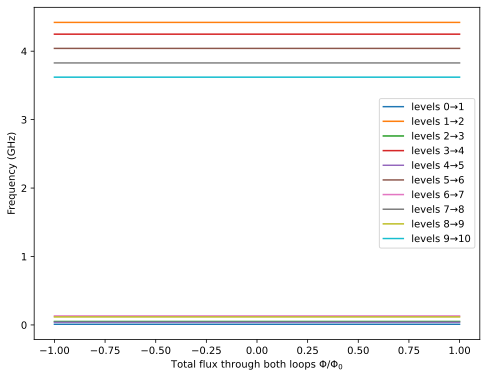

In [46]:
transitions = np.diff(evals, axis=1) # shape = (len(flux_vals), evals_count-1), compute transition frequencies between adjacent levels

x = 2*flux_vals # total flux through both loops, since Φ1 = -Φ2 = φ, total flux is 2*φ. This is the x-axis for the plot
freq01 = transitions[:, 0] # GHz
# anharm_mhz = (transitions[:, 1] - transitions[:, 0]) * 1e3  # MHz, anharmonicity is the difference between 1→2 and 0→1 transition frequencies

plt.figure(figsize=(8,6))
# Left axis: 0→1 frequency (GHz)
for i in range(10):
    plt.plot(x, transitions[:, i], label=f'levels {i}→{i+1}')
plt.xlabel(r'Total flux through both loops $\Phi/\Phi_0$')
plt.ylabel('Frequency (GHz)')
plt.legend()

plt.show()

In [17]:
yaml_str = """
branches:
  # Transmon qubit
  - [JJ, 1, 0, EJq = 18.3 GHz, CJq = 0.134 GHz]  # transmon junction
"""

circ = scq.Circuit(yaml_str, from_file=False) # create circuit object from yaml string

evals = circ.eigenvals(evals_count=11)

print(evals - evals[0])  # print energies relative to ground state

[ 0.          4.32105977  8.6117566  13.00763922 17.59355924 22.29518568
 26.86997611 31.08388144 33.6532375  39.35563283 39.45154926]


In [39]:
yaml_str = """
branches:
  # Linc circuit
  # two Josephson junctions and inductor in parallel form a SQUID loop between node 1 and ground
  - [JJ, 1, 0, EJ1 = 30,  CJ1 = 10000]   # GHz units if no unit suffix provided. These are capacitive charging energies
  - [JJ, 1, 0, EJ2 = 30,  CJ2 = 10000]   # use large charging energy to remove junction capacitance
  - [L,  1, 0, Ls = 3.5nH] # linc shunt inductor         
  # shunt capacitor (sets EC)
  - [C,  1, 0, Csh = 200fF]  # GHz units, capactive charging energy           
"""

circ = scq.Circuit(yaml_str, from_file=False) # create circuit object from yaml string
closure_idx = [0,1] # want the two JJs in loop to be the closure branches. This is index
closure_branches = [circ.branches[i] for i in closure_idx] # list of branches for the closure branches

# Re-define the loop basis
circ.configure(closure_branches=closure_branches)

# Verify
print(circ.sym_external_fluxes()) # now Φ1, Φ2 correspond to chosen loops above. IMPORTANT: check order of branches which determines line integral direction for flux loops. Note the direction when applying flux
circ.cutoff_ext_1 = 600 # set the cutoff for the hilbert space, in ext case it is fock space since using ladder operators


{Φ1: (Branch(JJ, 1, 0, index: 0), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 0)]), Φ2: (Branch(JJ, 1, 0, index: 1), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 1)])}


In [40]:
# 1) get the Unicode flux variable names from the circuit
flux_syms  = list(circ.sym_external_fluxes().keys())   # [Symbol('Φ1'), Symbol('Φ2'), ...]
phi1_name  = flux_syms[0].name                          # "Φ1"
phi2_name  = flux_syms[1].name                          # "Φ2"

# 2) sweep a common flux -1 to 1
flux_vals = np.linspace(-0.5, 0.5, 30) # this is equal to flux / Φ0

# 3) want symetric flux through both loops
evals_count = 15  # total hilbert space size
evals = np.empty((len(flux_vals), evals_count)) # eigenvalues for each flux value, for the first 6 levels
for i, phi in enumerate(flux_vals):
    setattr(circ, phi1_name, -phi)   # circ.Φ1 = -phi since the loop is defined in the opposite direction
    setattr(circ, phi2_name, phi)   # circ.Φ2 phi
    evals[i, :] = circ.eigenvals(evals_count=evals_count) # get eigenvalues for the current flux values

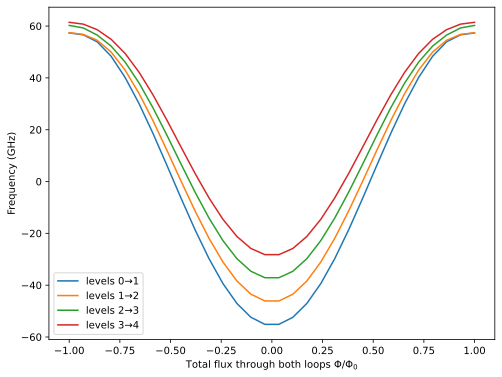

In [41]:
transitions = np.diff(evals, axis=1) # shape = (len(flux_vals), evals_count-1), compute transition frequencies between adjacent levels

x = 2*flux_vals # total flux through both loops, since Φ1 = -Φ2 = φ, total flux is 2*φ. This is the x-axis for the plot
freq01 = transitions[:, 0] # GHz
# anharm_mhz = (transitions[:, 1] - transitions[:, 0]) * 1e3  # MHz, anharmonicity is the difference between 1→2 and 0→1 transition frequencies

plt.figure(figsize=(8,6))
# Left axis: 0→1 frequency (GHz)
for i in range(4):
    plt.plot(x, evals[:, i], label=f'levels {i}→{i+1}')
plt.xlabel(r'Total flux through both loops $\Phi/\Phi_0$')
plt.ylabel('Frequency (GHz)')
plt.legend()

plt.show()